Emigrate
========
Emigrate is an electrophoresis simulator written in python. It is based on the the scipy.integrate.ode solver. It is written with multiple simulation modules to allow varying solution schemes in order to allow easy extension.

First, we'll import emigrate. We'll also import ionize, because it contains the Ion and Solution objects that we will use to set the initial conditions
We'll also import numpy to set up some vectors, and cProfile for code profiling

In [26]:
import emigrate
import ionize

import cProfile
import time

# from matplotlib import pyplot as plot
from matplotlib.pyplot import *
%matplotlib inline

## Non-focusing Example

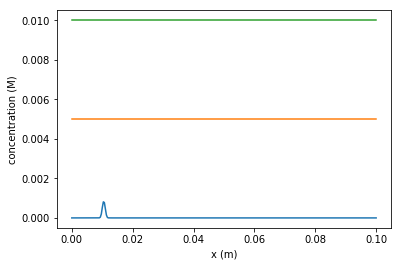

In [27]:
separation_buffer = ionize.Solution(['tris', 'hydrochloric acid'], [.01, .005])
solutions = [separation_buffer,
             separation_buffer + ionize.Solution(['alexa fluor 488'], [.001]), 
             separation_buffer]
system = emigrate.Frame(dict(lengths=[.01, .001, .089],
                         n_nodes=300,
                         interface_length=.0005,
                         solutions=solutions,
                         current=-500,
                         domain_mode='left', 
                         ))
for i in range(len(system.ions)):
    plot(system.nodes, system.concentrations[i,:])
xlabel('x (m)')
ylabel('concentration (M)')
show()

In [28]:
solver = emigrate.Solver(system, precondition=False, flux_mode='slip')
tmax = 200
dt = 1

epoch = time.time()
sequence = solver.solve('demos/non_focusing.hdf5', dt, tmax)
print('Solved in {:.2f} seconds.'.format(time.time()-epoch))

Solved in 378.52 seconds.


## Focused Example

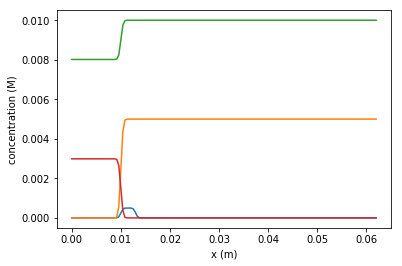

In [29]:
separation_buffer = ionize.Solution(['tris', 'hydrochloric acid'], [.01, .005])
trailing_electrolyte = separation_buffer.displace('chloride', 'hepes')
solutions = [trailing_electrolyte,
             separation_buffer + ionize.Solution(['alexa fluor 488'], [.0005]), 
             separation_buffer]
system = emigrate.Frame(dict(lengths=[.01, .003, .049],
                         n_nodes=150,
                         interface_length=.0005,
                         solutions=solutions,
                         current=-500,
                         domain_mode='left', 
                         ))
for i in range(len(system.ions)):
    plot(system.nodes, system.concentrations[i,:])
xlabel('x (m)')
ylabel('concentration (M)')
show()

In [30]:
solver = emigrate.Solver(system, precondition=True, flux_mode='slip')
tmax = 40
dt = 0.1

epoch = time.time()
sequence = solver.solve('demos/focusing.hdf5', dt, tmax)
print('Solved in {:.2f} seconds.'.format(time.time()-epoch))

Solved in 303.84 seconds.


## Stepping through concentration boundaries

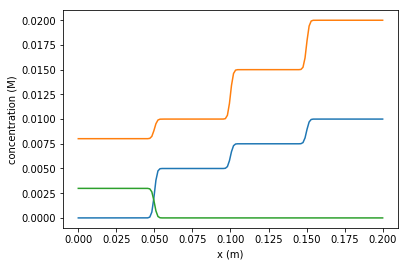

In [31]:
separation_buffer = ionize.Solution(['tris', 'hydrochloric acid'], [.01, .005])
trailing_electrolyte = separation_buffer.displace('chloride', 'hepes')
solutions = [trailing_electrolyte,
             separation_buffer, 
             separation_buffer*1.5,
             separation_buffer*2,
             ]
system = emigrate.Frame(dict(lengths=[0.05]*len(solutions),
                         n_nodes=150,
                         interface_length=.002,
                         solutions=solutions,
                         current=-500,
                         domain_mode='left', 
                         ))
for i in range(len(system.ions)):
    plot(system.nodes, system.concentrations[i,:])
xlabel('x (m)')
ylabel('concentration (M)')
show()

In [32]:
solver = emigrate.Solver(system, precondition=True, flux_mode='slip')
tmax = 200
dt = 0.1

epoch = time.time()
sequence = solver.solve('demos/stepping.hdf5', dt, tmax)
print('Solved in {:.2f} seconds.'.format(time.time()-epoch))

Solved in 371.17 seconds.
